### Step 1: Mount the Google Drive

Remember to use GPU runtime before mounting your Google Drive. (Runtime --> Change runtime type).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Step 2: Open the project directory

Replace `Your_Dir` with your own path.

In [ ]:
cd /content/drive/MyDrive/emg2qwerty-Detection-main/

/content/drive/MyDrive/emg2qwerty-Detection-main


### Step 3: Install required packages

After installing them, Colab will require you to restart the session.

In [ ]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.6/553.6 kB 599.0 kB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 7.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of typer to determine which version is

### Step 4: Start your experiments!

- Remember to download and copy the dataset to this directory: `Your_Dir/emg2qwerty/data`.
- You may now start your experiments with any scripts! Below are examples of single-user training and testing (greedy decoding).
- **There are two ways to track the logs:**
  - 1. Keep `--multirun`, and the logs will not be printed here, but they will be saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/submitit_logs/`.
  - 2. Comment out `--multirun` and the logs will be printed in this notebook, but they will not be saved.

#### Training

- The checkpoints are saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/checkpoints/`.

In [ ]:
!python -m emg2qwerty.train \
user="single_user" \
model=recurrent_lstm_ctc \
transforms=log_spectrogram \
trainer.accelerator=gpu trainer.devices=1 \
trainer.max_epochs=40

[2026-03-09 02:56:45,974][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

In [ ]:
!python -m emg2qwerty.train \
user="single_user" \
model=recurrent_lstm_ctc \
transforms=log_spectrogram \
band_rotation.transform.offsets="[0]" \
trainer.accelerator=gpu trainer.devices=1 \
trainer.max_epochs=40

[2026-03-09 03:25:48,161][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

In [ ]:
!python -m emg2qwerty.train \
user="single_user" \
model=recurrent_lstm_ctc \
transforms=log_spectrogram \
temporal_jitter.max_offset=0 \
trainer.accelerator=gpu trainer.devices=1 \
trainer.max_epochs=40

[2026-03-09 03:52:03,324][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

In [ ]:
!python -m emg2qwerty.train \
user="single_user" \
model=recurrent_lstm_ctc \
transforms=log_spectrogram \
specaug.n_time_masks=5 \
specaug.time_mask_param=40 \
specaug.n_freq_masks=3 \
specaug.freq_mask_param=6 \
trainer.accelerator=gpu trainer.devices=1 \
trainer.max_epochs=40

[2026-03-09 04:22:55,498][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

In [ ]:
!python -m emg2qwerty.train \
user="single_user" \
model=recurrent_lstm_ctc \
transforms=log_spectrogram \
specaug.n_time_masks=0 \
specaug.n_freq_masks=0 \
band_rotation.transform.offsets="[0]" \
temporal_jitter.max_offset=0 \
trainer.accelerator=gpu trainer.devices=1 \
trainer.max_epochs=40

[2026-03-09 04:45:21,003][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

In [ ]:
!python -m emg2qwerty.train \
user="single_user" \
model=recurrent_lstm_ctc \
transforms=log_spectrogram \
logspec.hop_length=8 \
trainer.accelerator=gpu trainer.devices=1 \
trainer.max_epochs=40

[2026-03-09 05:18:32,465][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

In [ ]:
import os
import pandas as pd
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Change this if your runs are under a different date folder.
base_dir = "logs/2026-03-09"

# Put these in the SAME ORDER you launched the 6 official 40-epoch runs.
experiment_names = [
    "baseline_default_aug",
    "no_band_rotation",
    "no_temporal_jitter",
    "strong_specaug",
    "no_aug",
    "faster_hop_8",
]

def read_last_scalar(ea, tag):
    try:
        items = ea.Scalars(tag)
        return items[-1].value if items else None
    except Exception:
        return None

rows = []

for run in sorted(os.listdir(base_dir)):
    run_dir = os.path.join(base_dir, run)
    if not os.path.isdir(run_dir):
        continue

    lightning_root = os.path.join(run_dir, "lightning_logs")
    if not os.path.exists(lightning_root):
        continue

    version_dirs = sorted(
        [d for d in os.listdir(lightning_root) if os.path.isdir(os.path.join(lightning_root, d))]
    )
    if not version_dirs:
        continue

    tb_dir = os.path.join(lightning_root, version_dirs[0])

    try:
        ea = EventAccumulator(tb_dir)
        ea.Reload()
    except Exception as e:
        print(f"Skipping {run}: could not read TensorBoard logs ({e})")
        continue

    row = {
        "run": run,
        "val_CER": read_last_scalar(ea, "val/CER"),
        "test_CER": read_last_scalar(ea, "test/CER"),
        "val_loss": read_last_scalar(ea, "val/loss"),
        "test_loss": read_last_scalar(ea, "test/loss"),
    }
    rows.append(row)

df = pd.DataFrame(rows).sort_values("run").reset_index(drop=True)

# Remove the 3-epoch sanity run.
# Usually it has test_CER = 100. If needed, replace this filter with df = df.iloc[1:].
df = df[df["test_CER"].notna()].copy()
df = df[df["test_CER"] < 90].reset_index(drop=True)

# Safety check
if len(df) != 6:
    print(f"Warning: expected 6 official runs, found {len(df)} runs after filtering.")
    display(df)

# Attach experiment names in launch order
df["experiment"] = experiment_names[:len(df)]

# Reorder columns to match your desired table
df = df[["experiment", "val_CER", "test_CER", "val_loss", "test_loss"]]
df = df.sort_values("test_CER").reset_index(drop=True)


display(df)

,experiment,val_CER,test_CER,val_loss,test_loss
0,no_band_rotation,19.229065,19.170088,0.638075,0.614746
1,no_aug,18.763845,20.358765,0.643969,0.674739
2,baseline_default_aug,20.425343,21.590664,0.674041,0.686772
3,no_temporal_jitter,22.108994,22.909012,0.727999,0.724336
4,strong_specaug,24.501551,27.080181,0.814011,0.865335
5,faster_hop_8,26.805494,27.425978,0.862274,0.872644


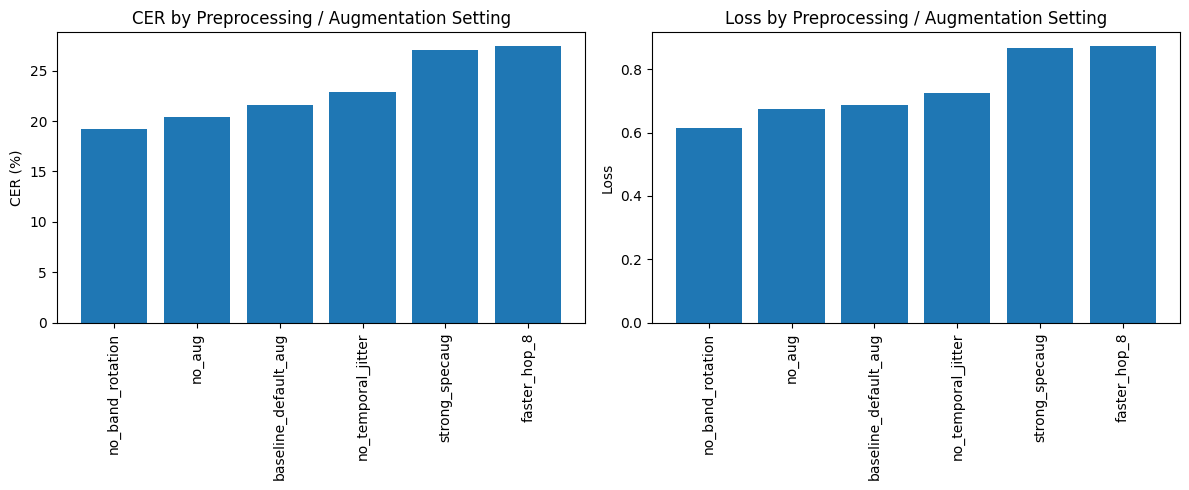

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(df["experiment"], df["test_CER"])
plt.ylabel("CER (%)")
plt.title("CER by Preprocessing / Augmentation Setting")
plt.xticks(rotation=90)

plt.subplot(1,2,2)
plt.bar(df["experiment"], df["test_loss"])
plt.ylabel("Loss")
plt.title("Loss by Preprocessing / Augmentation Setting")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

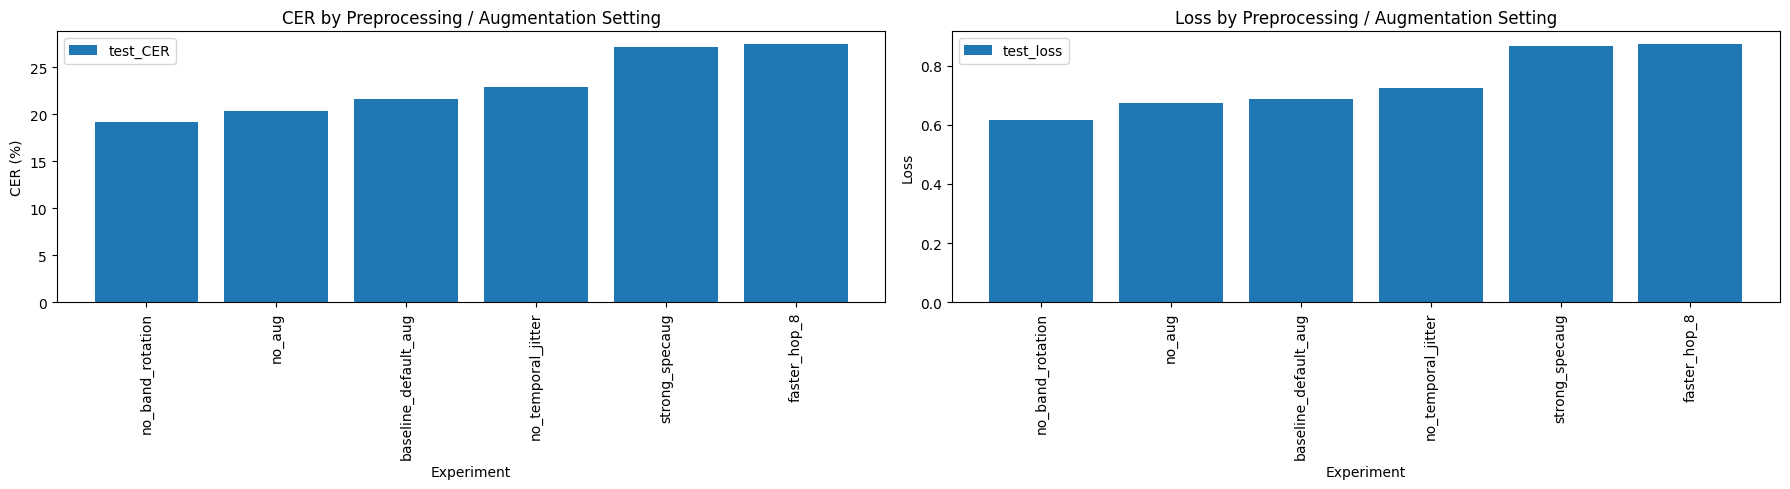

,experiment,val_CER,test_CER,val_loss,test_loss
0,no_band_rotation,19.229065,19.170088,0.638075,0.614746
1,no_aug,18.763845,20.358765,0.643969,0.674739
2,baseline_default_aug,20.425343,21.590664,0.674041,0.686772
3,no_temporal_jitter,22.108994,22.909012,0.727999,0.724336
4,strong_specaug,24.501551,27.080181,0.814011,0.865335
5,faster_hop_8,26.805494,27.425978,0.862274,0.872644


In [ ]:
import matplotlib.pyplot as plt
from IPython.display import display

df = df.sort_values("test_CER").reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Left plot: CER
axes[0].bar(df["experiment"], df["test_CER"], label="test_CER")
axes[0].set_title("CER by Preprocessing / Augmentation Setting")
axes[0].set_ylabel("CER (%)")
axes[0].set_xlabel("Experiment")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=90)

# Right plot: Loss
axes[1].bar(df["experiment"], df["test_loss"], label="test_loss")
axes[1].set_title("Loss by Preprocessing / Augmentation Setting")
axes[1].set_ylabel("Loss")
axes[1].set_xlabel("Experiment")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

display(df)

In [ ]:
fig.savefig("preprocessing_lstm_plots.png", dpi=300, bbox_inches="tight")

In [ ]:
df.to_csv("preprocessing_lstm_table.csv", index=False)

In [ ]:
!python -m emg2qwerty.train \
  user="single_user" \
  model=recurrent_lstm_ctc \
  transforms=channels_drop \
  channel_select.n_left=16 \
  channel_select.n_right=16 \
  trainer.accelerator=gpu trainer.devices=1 \
  trainer.max_epochs=40

[2026-03-09 06:28:25,125][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

In [ ]:
!python -m emg2qwerty.train \
  user="single_user" \
  model=recurrent_lstm_ctc \
  transforms=channels_drop \
  channel_select.n_left=12 \
  channel_select.n_right=12 \
  module.in_features=396 \
  +module.electrode_channels=12 \
  trainer.accelerator=gpu \
  trainer.devices=1 \
  trainer.max_epochs=40

[2026-03-09 07:12:05,995][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

In [ ]:
!python -m emg2qwerty.train \
  user="single_user" \
  model=recurrent_lstm_ctc \
  transforms=channels_drop \
  channel_select.n_left=8 \
  channel_select.n_right=8 \
  module.in_features=264 \
  +module.electrode_channels=8 \
  trainer.accelerator=gpu \
  trainer.devices=1 \
  trainer.max_epochs=40

[2026-03-09 07:28:45,358][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

In [ ]:
!python -m emg2qwerty.train \
  user="single_user" \
  model=recurrent_lstm_ctc \
  transforms=channels_drop \
  channel_select.n_left=4 \
  channel_select.n_right=4 \
  module.in_features=132 \
  +module.electrode_channels=4 \
  trainer.accelerator=gpu \
  trainer.devices=1 \
  trainer.max_epochs=40

[2026-03-09 07:43:52,397][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

In [ ]:
!python -m emg2qwerty.train \
  user="single_user" \
  model=recurrent_lstm_ctc \
  transforms=channels_drop \
  channel_select.n_left=2 \
  channel_select.n_right=2 \
  module.in_features=66 \
  +module.electrode_channels=2 \
  trainer.accelerator=gpu \
  trainer.devices=1 \
  trainer.max_epochs=40

[2026-03-09 08:08:25,841][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

   channels        cer
4         2  60.988037
3         4  59.858219
2         8  32.897652
1        12  25.431990
0        16  20.425343


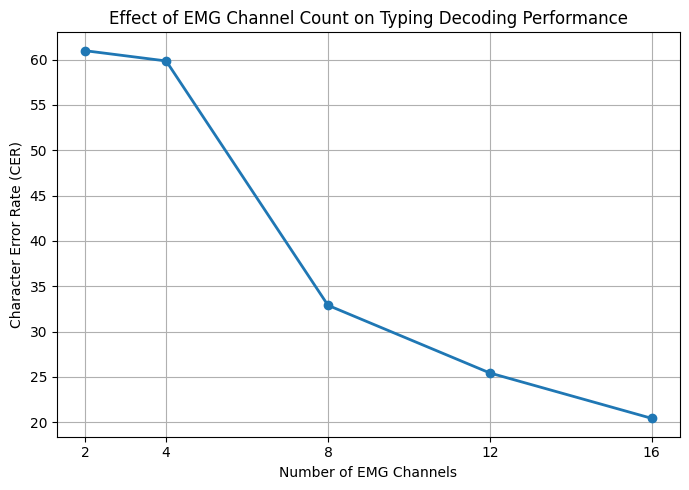

Saved to Google Drive: channel_vs_cer.png


In [ ]:
import os
import glob
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

LOG_ROOT = "/content/drive/MyDrive/emg2qwerty-Detection-main/logs/2026-03-09"

runs = sorted(glob.glob(os.path.join(LOG_ROOT, "*")))

results = []

for run in runs:

    cfg_path = os.path.join(run, "hydra_configs", "config.yaml")
    if not os.path.exists(cfg_path):
        continue

    with open(cfg_path) as f:
        cfg = yaml.safe_load(f)

    try:
        channels = cfg["channel_select"]["n_left"]
    except:
        continue

    event_files = glob.glob(os.path.join(run, "lightning_logs", "**", "events*"), recursive=True)

    if len(event_files) == 0:
        continue

    event_file = event_files[0]

    ea = EventAccumulator(event_file)
    ea.Reload()

    tags = ea.Tags()["scalars"]

    cer_tag = None
    for t in tags:
        if "CER" in t and "val" in t:
            cer_tag = t
            break

    if cer_tag is None:
        continue

    cer_events = ea.Scalars(cer_tag)

    cer_values = [e.value for e in cer_events]

    if len(cer_values) == 0:
        continue

    best_cer = min(cer_values)

    results.append((channels, best_cer))


# ---------- 转 dataframe ----------
df = pd.DataFrame(results, columns=["channels", "cer"])

df = df.sort_values("channels")

print(df)


# ---------- 画图 ----------
plt.figure(figsize=(7,5))

plt.plot(
    df["channels"],
    df["cer"],
    marker="o",
    linewidth=2
)

plt.xlabel("Number of EMG Channels")
plt.ylabel("Character Error Rate (CER)")
plt.title("Effect of EMG Channel Count on Typing Decoding Performance")

plt.xticks(df["channels"])
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/channel_vs_cer.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to Google Drive: channel_vs_cer.png")

In [ ]:
plt.savefig("channel_vs_cer.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [ ]:
!python -m emg2qwerty.train \
  user=data_amount_generated/data_amount_01_sessions \
  model=recurrent_lstm_ctc \
  transforms=log_spectrogram \
  trainer.accelerator=gpu trainer.devices=1 \
  trainer.max_epochs=40

[2026-03-09 17:24:53,850][__main__][INFO] - 
Config:
user: data_amount_01_sessions
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622764398-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  val:
  - user: 89335547
    session: 2021-06-04-1622862148-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  test:
  - user: 89335547
    session: 2021-06-02-1622682789-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  root: ${hydra:runtime.cwd}/data
to_tensor:
  _target_: emg2qwerty.transforms.ToTensor
  fields:
  - emg_left
  - emg_right
band_rotation:
  _target_: emg2qwerty.transforms.ForEach
  transform:
    _target_: emg2qwerty.transforms.RandomBandRotation
    offsets:
    - -1
    - 0
    - 1
temporal_jitter:
  _target_: emg2qwerty.transforms.TemporalAlignmentJitter
  max_offset: 120
logspec:
  _target_: emg2qwerty.transforms.LogSpectrogram
  n_fft: 64
  hop_length: 16
specaug:
  _target_: emg2qwerty.transforms.SpecAugment
  n_time_masks: 3
 

In [ ]:
!python -m emg2qwerty.train \
  user=data_amount_generated/data_amount_02_sessions \
  model=recurrent_lstm_ctc \
  transforms=log_spectrogram \
  trainer.accelerator=gpu trainer.devices=1 \
  trainer.max_epochs=40

[2026-03-09 17:28:48,858][__main__][INFO] - 
Config:
user: data_amount_02_sessions
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622764398-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622884635-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  val:
  - user: 89335547
    session: 2021-06-04-1622862148-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  test:
  - user: 89335547
    session: 2021-06-02-1622682789-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  root: ${hydra:runtime.cwd}/data
to_tensor:
  _target_: emg2qwerty.transforms.ToTensor
  fields:
  - emg_left
  - emg_right
band_rotation:
  _target_: emg2qwerty.transforms.ForEach
  transform:
    _target_: emg2qwerty.transforms.RandomBandRotation
    offsets:
    - -1
    - 0
    - 1
temporal_jitter:
  _target_: emg2qwerty.transforms.TemporalAlignmentJitter
  max_offset: 120
logspec:
  _target_: emg2qwerty.transforms.LogS

In [ ]:
!python -m emg2qwerty.train \
  user=data_amount_generated/data_amount_04_sessions \
  model=recurrent_lstm_ctc \
  transforms=log_spectrogram \
  trainer.accelerator=gpu trainer.devices=1 \
  trainer.max_epochs=40

[2026-03-09 17:33:32,062][__main__][INFO] - 
Config:
user: data_amount_04_sessions
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622764398-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622884635-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626915176-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  val:
  - user: 89335547
    session: 2021-06-04-1622862148-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  test:
  - user: 89335547
    session: 2021-06-02-1622682789-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  root: ${hydra:runtime.cwd}/data
to_tensor:
  _target_: emg2qwerty.transforms.ToTensor
  fields:
  - emg_left
  - emg_right
band_rotation:
  _target_: emg2qwerty.transforms.ForEach
  transform:
    _

In [ ]:
!python -m emg2qwerty.train \
  user=data_amount_generated/data_amount_08_sessions \
  model=recurrent_lstm_ctc \
  transforms=log_spectrogram \
  trainer.accelerator=gpu trainer.devices=1 \
  trainer.max_epochs=40

[2026-03-09 17:40:10,912][__main__][INFO] - 
Config:
user: data_amount_08_sessions
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622764398-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622884635-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626915176-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-03-1622766673-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627001995-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622861066-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-

In [ ]:
!python -m emg2qwerty.train \
  user=data_amount_generated/data_amount_12_sessions \
  model=recurrent_lstm_ctc \
  transforms=log_spectrogram \
  trainer.accelerator=gpu trainer.devices=1 \
  trainer.max_epochs=40

[2026-03-09 17:51:04,258][__main__][INFO] - 
Config:
user: data_amount_12_sessions
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622764398-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622884635-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626915176-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-03-1622766673-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627001995-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622861066-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-

In [ ]:
!python -m emg2qwerty.train \
  user=data_amount_generated/data_amount_16_sessions \
  model=recurrent_lstm_ctc \
  transforms=log_spectrogram \
  trainer.accelerator=gpu trainer.devices=1 \
  trainer.max_epochs=40

[2026-03-09 18:06:03,073][__main__][INFO] - 
Config:
user: data_amount_16_sessions
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622764398-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622884635-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626915176-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-03-1622766673-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627001995-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622861066-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-

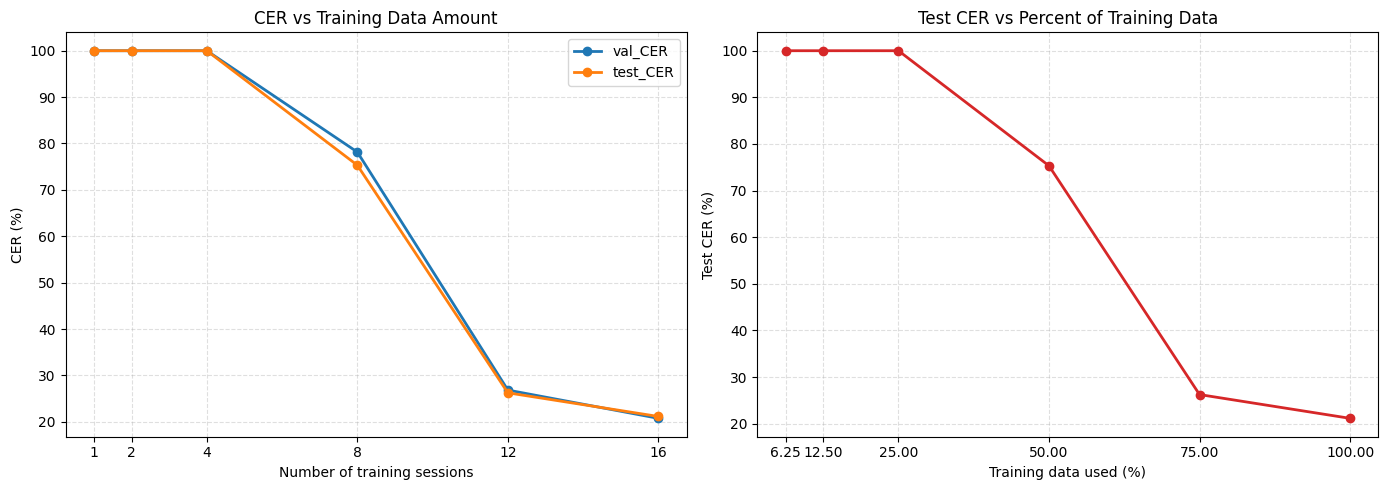


Plot summary:
data_amount_01_sessions | sessions = 1 | fraction = 0.06 | val_CER = 100.0 | test_CER = 100.0 | status = complete
data_amount_02_sessions | sessions = 2 | fraction = 0.12 | val_CER = 100.0 | test_CER = 100.0 | status = complete
data_amount_04_sessions | sessions = 4 | fraction = 0.25 | val_CER = 100.0 | test_CER = 100.0 | status = complete
data_amount_08_sessions | sessions = 8 | fraction = 0.50 | val_CER = 78.156845 | test_CER = 75.31877899169922 | status = complete
data_amount_12_sessions | sessions = 12 | fraction = 0.75 | val_CER = 26.8498 | test_CER = 26.258914947509766 | status = complete
data_amount_16_sessions | sessions = 16 | fraction = 1.00 | val_CER = 20.757643 | test_CER = 21.158418655395508 | status = complete


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace with your actual results
data = {
    "sessions": [1, 2, 4, 8, 12, 16],
    "fraction": [1/16, 2/16, 4/16, 8/16, 12/16, 16/16],
    "val_CER": [100.0, 100.0, 100.0, 78.156845, 26.849800, 20.757643],
    "test_CER": [100.0, 100.0, 100.0, 75.31877899169922, 26.258914947509766, 21.158418655395508],
    "status": ["complete"] * 6,
    "name": [
        "data_amount_01_sessions",
        "data_amount_02_sessions",
        "data_amount_04_sessions",
        "data_amount_08_sessions",
        "data_amount_12_sessions",
        "data_amount_16_sessions",
    ],
}

df = pd.DataFrame(data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="white")

# Left plot
axes[0].plot(df["sessions"], df["val_CER"], marker="o", linewidth=2, label="val_CER")
axes[0].plot(df["sessions"], df["test_CER"], marker="o", linewidth=2, label="test_CER")
axes[0].set_title("CER vs Training Data Amount")
axes[0].set_xlabel("Number of training sessions")
axes[0].set_ylabel("CER (%)")
axes[0].set_xticks(df["sessions"])
axes[0].grid(True, linestyle="--", alpha=0.4)
axes[0].legend()

# Right plot
axes[1].plot(df["fraction"] * 100, df["test_CER"], marker="o", linewidth=2, color="tab:red")
axes[1].set_title("Test CER vs Percent of Training Data")
axes[1].set_xlabel("Training data used (%)")
axes[1].set_ylabel("Test CER (%)")
axes[1].set_xticks((df["fraction"] * 100).tolist())
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

print("\nPlot summary:")
for _, row in df.iterrows():
    print(
        f"{row['name']} | "
        f"sessions = {int(row['sessions'])} | "
        f"fraction = {row['fraction']:.2f} | "
        f"val_CER = {row['val_CER']} | "
        f"test_CER = {row['test_CER']} | "
        f"status = {row['status']}"
    )

In [ ]:
# 125 Hz
!python -m emg2qwerty.train \
  user="single_user" \
  model=recurrent_lstm_ctc \
  transforms=sampling_rate \
  module.in_features=48 \
  trainer.accelerator=gpu \
  trainer.devices=1 \
  trainer.max_epochs=40

[2026-03-09 19:03:48,074][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

In [ ]:
# 250 Hz
!python -m emg2qwerty.train \
  user="single_user" \
  model=recurrent_lstm_ctc \
  transforms=sampling_rate \
  time_downsample.stride=8 \
  logspec.n_fft=8 \
  logspec.hop_length=2 \
  module.in_features=80 \
  trainer.accelerator=gpu \
  trainer.devices=1 \
  trainer.max_epochs=40

[2026-03-09 19:15:47,477][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

In [ ]:
# 500 Hz
!python -m emg2qwerty.train \
  user="single_user" \
  model=recurrent_lstm_ctc \
  transforms=sampling_rate \
  time_downsample.stride=4 \
  logspec.n_fft=16 \
  logspec.hop_length=4 \
  module.in_features=144 \
  trainer.accelerator=gpu \
  trainer.devices=1 \
  trainer.max_epochs=40

[2026-03-09 19:28:03,358][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

In [ ]:
# 1000 Hz
!python -m emg2qwerty.train \
  user="single_user" \
  model=recurrent_lstm_ctc \
  transforms=sampling_rate \
  time_downsample.stride=2 \
  logspec.n_fft=32 \
  logspec.hop_length=8 \
  module.in_features=272 \
  trainer.accelerator=gpu \
  trainer.devices=1 \
  trainer.max_epochs=40

[2026-03-09 19:40:51,280][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

In [ ]:
# 2000 Hz
!python -m emg2qwerty.train \
  user="single_user" \
  model=recurrent_lstm_ctc \
  transforms=sampling_rate \
  time_downsample.stride=1 \
  logspec.n_fft=64 \
  logspec.hop_length=16 \
  module.in_features=528 \
  trainer.accelerator=gpu \
  trainer.devices=1 \
  trainer.max_epochs=40

#### Testing:

- Replace `Your_Path_to_Checkpoint` with your checkpoint path.

In [ ]:
# Single-user testing
!python -m emg2qwerty.train \
  user="single_user" \
  checkpoint="/content/drive/MyDrive/emg2qwerty/logs/2026-03-04/08-32-24/checkpoints/epoch\=39-step\=4800.ckpt" \
  train=False trainer.accelerator=gpu \
  decoder=ctc_greedy \
  hydra.launcher.mem_gb=64 \
  # --multirun

[2026-03-04 09:06:47,755][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

Baseline metrics:
val_CER: 22.552061080932617
val_IER: 5.981391429901123
val_DER: 2.0602569580078125
val_SER: 14.510412216186523
val_loss: 0.7416194677352905
test_CER: 24.18413734436035
test_IER: 6.267560005187988
test_DER: 2.139615297317505
test_SER: 15.776961326599121
test_loss: 0.7690999507904053


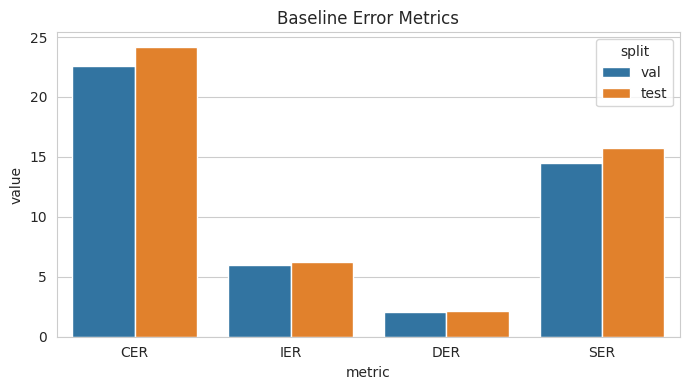

In [ ]:
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorboard.backend.event_processing import event_accumulator

RUN_DIR = "/content/drive/MyDrive/emg2qwerty/logs/2026-03-04/09-06-47"

def get_last_from_events(run_dir, tag_candidates):
    event_files = sorted(
        glob.glob(os.path.join(run_dir, "lightning_logs", "version_*", "events.out.tfevents*")),
        key=os.path.getmtime
    )
    latest_val = None
    for ev in event_files:
        try:
            ea = event_accumulator.EventAccumulator(ev)
            ea.Reload()
            tags = set(ea.Tags().get("scalars", []))
            for t in tag_candidates:
                if t in tags:
                    vals = ea.Scalars(t)
                    if vals:
                        latest_val = vals[-1].value  # keep latest found across files
        except Exception:
            pass
    return latest_val

def get_from_log(run_dir, key):
    log_path = os.path.join(run_dir, "emg2qwerty.log")
    if not os.path.exists(log_path):
        return None
    with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
        txt = f.read()

    # dict-style print at end: 'val/CER': 22.55
    m = re.findall(rf"'{re.escape(key)}'\s*:\s*([0-9]+(?:\.[0-9]+)?)", txt)
    if m:
        return float(m[-1])

    # table style
    m = re.findall(rf"{re.escape(key)}\s*[\|\u2502]\s*([0-9]+(?:\.[0-9]+)?)", txt)
    if m:
        return float(m[-1])

    return None

def metric(run_dir, key, tag_candidates):
    v = get_last_from_events(run_dir, tag_candidates)
    if v is None:
        v = get_from_log(run_dir, key)
    return v

metrics = {
    "val_CER":  metric(RUN_DIR, "val/CER",  ["val/CER", "val/CER_epoch", "val_cer"]),
    "val_IER":  metric(RUN_DIR, "val/IER",  ["val/IER", "val/IER_epoch"]),
    "val_DER":  metric(RUN_DIR, "val/DER",  ["val/DER", "val/DER_epoch"]),
    "val_SER":  metric(RUN_DIR, "val/SER",  ["val/SER", "val/SER_epoch"]),
    "val_loss": metric(RUN_DIR, "val/loss", ["val/loss", "val/loss_epoch", "val_loss"]),
    "test_CER":  metric(RUN_DIR, "test/CER",  ["test/CER", "test/CER_epoch", "test_cer"]),
    "test_IER":  metric(RUN_DIR, "test/IER",  ["test/IER", "test/IER_epoch"]),
    "test_DER":  metric(RUN_DIR, "test/DER",  ["test/DER", "test/DER_epoch"]),
    "test_SER":  metric(RUN_DIR, "test/SER",  ["test/SER", "test/SER_epoch"]),
    "test_loss": metric(RUN_DIR, "test/loss", ["test/loss", "test/loss_epoch", "test_loss"]),
}

print("Baseline metrics:")
for k, v in metrics.items():
    print(f"{k}: {v}")

# Save
pd.DataFrame([metrics]).to_csv(os.path.join(RUN_DIR, "baseline_metrics.csv"), index=False)

# Plot
sns.set_style("whitegrid")
err_df = pd.DataFrame({
    "metric": ["CER", "IER", "DER", "SER"],
    "val": [metrics["val_CER"], metrics["val_IER"], metrics["val_DER"], metrics["val_SER"]],
    "test": [metrics["test_CER"], metrics["test_IER"], metrics["test_DER"], metrics["test_SER"]],
}).melt(id_vars="metric", var_name="split", value_name="value").dropna()

plt.figure(figsize=(7,4))
sns.barplot(data=err_df, x="metric", y="value", hue="split")
plt.title("Baseline Error Metrics")
plt.tight_layout()
plt.show()